# 강원도 심화 분석 EDA

전국/강원도 날씨 EDA, 날씨-공간 통합 EDA, 원천 토지피복 심화 EDA 결과를 강원도 표본에 다시 결합해 분석한다.

핵심 질문은 다음과 같다.

- 영동/영서에 따라 발생일 악기상과 토지피복 맥락의 위험이 다르게 나타나는가?
- 발생 직전 24시간의 강풍·저습 복합 노출이 장시간 진화 및 대형 피해 꼬리와 연결되는가?
- W/SW 사면-풍향 정렬 신호가 주변 산림 방향·거리와 결합할 때 영동에서만 강화되는가?
- 발생원인, 토지피복, 악기상을 3중으로 묶었을 때 모델링에 쓸 수 있는 조합이 남는가?
- 접근성 병목과 원격제어 불가능 조건은 악기상에서 어떤 조건부 신호를 보이는가?
- 시군구 단위 프로파일은 원자료 표기 품질 이슈를 감안해 어디까지 해석 가능한가?

결측 보간/대체는 하지 않고, 모든 표에는 유효 표본 수를 함께 확인한다.

## 0. 라이브러리 및 한글 폰트 설정

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from IPython.display import display

BASE_DIR = Path("D:/farm-system-public-02")
EDA_DIR = BASE_DIR / "jsw" / "EDA"
CONTEXT_PATH = EDA_DIR / "landcover_context_features.csv"
SPATIAL_PATH = EDA_DIR / "fire_spatial_features.csv"
WEATHER_DAY_PATH = BASE_DIR / "data" / "날씨데이터" / "날씨데이터_일자별_전국산불.csv"
WEATHER_HOUR_PATH = BASE_DIR / "data" / "날씨데이터" / "날씨데이터_시간별_전국산불.csv"
TMP_PLOT_DIR = EDA_DIR / "_tmp_gangwon_deep_plots"
TMP_PLOT_DIR.mkdir(exist_ok=True)

font_path = "C:/Windows/Fonts/malgun.ttf"
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

sns.set_theme(
    style="whitegrid",
    font=font_name,
    rc={
        "font.family": font_name,
        "font.sans-serif": [font_name],
        "axes.unicode_minus": False,
    },
)
plt.rcParams["font.family"] = font_name
plt.rcParams["font.sans-serif"] = [font_name]
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

print("현재 matplotlib font.family:", plt.rcParams["font.family"])
print("현재 matplotlib font.sans-serif:", plt.rcParams["font.sans-serif"][:3])

현재 matplotlib font.family: ['Malgun Gothic']
현재 matplotlib font.sans-serif: ['Malgun Gothic']


## 1. 데이터 로드 및 강원도 분석용 피처 생성

In [2]:
YEONGDONG_NAMES = {
    "강릉", "강릉시", "속초", "속초시", "동해", "동해시", "삼척", "삼척시",
    "태백", "태백시", "고성", "고성군", "양양", "양양군",
}

def cause_group(value):
    text = str(value)
    if text in ["0", "미상", "원인미상", "조사중", "nan", "None", ""]:
        return "미상/미기록"
    if any(k in text for k in ["논", "밭", "두렁", "농산", "쓰레기", "소각", "폐기물"]):
        return "소각/농업활동"
    if any(k in text for k in ["입산", "등산", "성묘", "산나물", "약초"]):
        return "입산/산림활동"
    if any(k in text for k in ["담뱃", "담배", "차량", "도로변"]):
        return "도로/담뱃불"
    if any(k in text for k in ["주택", "가옥", "건축", "보일러", "아궁이"]):
        return "주거/시설 비화"
    if any(k in text for k in ["용접", "공사", "작업"]):
        return "공사/작업"
    if any(k in text for k in ["방화", "불장난"]):
        return "방화/불장난"
    if "낙뢰" in text:
        return "자연/낙뢰"
    return "기타"

def directional_between(series, low, high):
    deg = pd.to_numeric(series, errors="coerce") % 360
    if low <= high:
        return deg.between(low, high, inclusive="both")
    return deg.ge(low) | deg.le(high)

def summarize_group(g):
    valid = g[g["_suppression_valid"]]
    damage = g["_damage_ha"].dropna()
    return pd.Series({
        "전체 N": len(g),
        "진화 유효 N": len(valid),
        "평균 진화시간(h)": valid["_suppression_hours"].mean(),
        "12h 이상 비율(%)": valid["_large_fire_12h"].mean() * 100 if len(valid) else np.nan,
        "10ha 이상 비율(%)": g["_large_damage_10ha"].mean() * 100,
        "평균 피해면적(ha)": damage.mean(),
        "중앙 피해면적(ha)": damage.median(),
        "90p 피해면적(ha)": damage.quantile(0.9),
        "최대 피해면적(ha)": damage.max(),
    })

In [3]:
ctx = pd.read_csv(CONTEXT_PATH, encoding="utf-8-sig", low_memory=False)
spatial_cols = [
    "fire_id", "연도", "월", "일", "시간", "고도(m)", "경사도(도)", "사면방향_sin", "사면방향_cos",
    "nearest_station_dist_km", "nearest_facility_dist_km", "nearest_facility_remote",
    "nearest_water_dist_km", "nearest_road_dist_km", "nearest_trail_dist_km",
    "산림지역_ratio", "시가화건조지역_ratio", "농업지역_ratio", "total_lc_area", "total_lc_area_norm",
]
spatial = pd.read_csv(SPATIAL_PATH, usecols=spatial_cols, encoding="utf-8-sig", low_memory=False)

weather_day = pd.read_csv(WEATHER_DAY_PATH, encoding="utf-8-sig", low_memory=False)
weather_occ = (
    weather_day[weather_day["날짜구분"].eq("발생일")]
    .rename(columns={"산불아이디": "fire_id"})
    [[
        "fire_id", "평균 풍속", "최대 순간풍속", "최대 순간 풍속 풍향", "최소 상대습도",
        "평균 상대습도", "평균 기온", "평균 이슬점온도", "평균 현지기압", "평균 지면온도", "최저 초상온도",
    ]]
)

hourly = pd.read_csv(
    WEATHER_HOUR_PATH,
    encoding="utf-8-sig",
    usecols=["산불아이디", "발생시각기준시간", "풍속", "습도"],
    low_memory=False,
).rename(columns={"산불아이디": "fire_id"})
pre24 = hourly[hourly["발생시각기준시간"].between(-24, 0)].copy()
pre24["wind3"] = pre24["풍속"].ge(3.0)
pre24["dry30"] = pre24["습도"].le(30.0)
pre24["wind_dry"] = pre24["wind3"] & pre24["dry30"]
exposure = (
    pre24.groupby("fire_id")
    .agg(
        pre24_hour_valid_n=("발생시각기준시간", "count"),
        pre24_wind3_hours=("wind3", "sum"),
        pre24_dry30_hours=("dry30", "sum"),
        pre24_wind_dry_hours=("wind_dry", "sum"),
        pre24_max_wind=("풍속", "max"),
        pre24_min_humidity=("습도", "min"),
    )
    .reset_index()
)

df = (
    ctx.merge(spatial, on="fire_id", how="left", suffixes=("", "_old"))
    .merge(weather_occ, on="fire_id", how="left")
    .merge(exposure, on="fire_id", how="left")
)
df = df[df["is_gangwon"].eq(True)].copy()

df["_suppression_hours"] = pd.to_numeric(df["진화소요시간(HH)"], errors="coerce")
df["_suppression_valid"] = df["_suppression_hours"].gt(0) & df["_suppression_hours"].notna()
df["_large_fire_12h"] = np.where(df["_suppression_valid"], df["_suppression_hours"].ge(12), np.nan)
df["_damage_ha"] = pd.to_numeric(df["피해면적(ha)"], errors="coerce")
df["_large_damage_10ha"] = df["_damage_ha"].ge(10)
df["landcover_context_type"] = df["landcover_context_type"].fillna("원천매칭없음")
df["point_landcover_major"] = df["point_landcover_major"].fillna("원천매칭없음")
df["landcover_missing_flag"] = df["landcover_context_type"].eq("원천매칭없음")
df["cause_group"] = df["발생원인명"].map(cause_group)
df["gangwon_region"] = np.where(df["발생지역시군구명"].astype(str).isin(YEONGDONG_NAMES), "영동", "영서")
df["spring_season"] = df["월"].between(3, 5)

weather_valid = df[["평균 풍속", "최대 순간풍속", "최소 상대습도"]].notna().any(axis=1)
df["weather_valid_day"] = weather_valid
df["wind_peak_day"] = (df["평균 풍속"].ge(3.0) | df["최대 순간풍속"].ge(7.0)) & weather_valid
df["dry_peak_day"] = df["최소 상대습도"].le(30.0) & weather_valid
df["weather_peak_day"] = (df["wind_peak_day"] | df["dry_peak_day"]) & weather_valid
df["weather_peak_label"] = np.select([~weather_valid, df["weather_peak_day"]], ["날씨결측", "악기상"], default="평시")

aspect_deg = (np.degrees(np.arctan2(df["사면방향_sin"], df["사면방향_cos"])) + 360) % 360
df["aspect_deg"] = aspect_deg
df["aspect_ws"] = directional_between(aspect_deg, 202.5, 292.5)
df["wind_ws"] = directional_between(df["최대 순간 풍속 풍향"], 202.5, 292.5)
df["aspect_wind_ws_match"] = df["aspect_ws"] & df["wind_ws"]
df["forest_near_30m"] = pd.to_numeric(df["nearest_forest_dist_m"], errors="coerce").le(30)
df["forest_direction_corridor"] = df["forest_dominant_direction"].isin(["E", "SE", "W", "SW"])
df["wind_forest_alignment"] = np.select(
    [
        df["aspect_wind_ws_match"] & df["forest_near_30m"] & df["forest_direction_corridor"],
        df["aspect_wind_ws_match"] & df["forest_near_30m"],
        df["aspect_wind_ws_match"],
    ],
    ["사면-풍향정렬+근접산림+E/SE/W/SW", "사면-풍향정렬+근접산림", "사면-풍향정렬"],
    default="그 외",
)

df["pre24_exposure_grade"] = pd.cut(
    df["pre24_wind_dry_hours"],
    bins=[-0.1, 0, 3, 8, 25],
    labels=["복합노출 없음", "1-3h", "4-8h", "9h 이상"],
)

dist_cols = ["nearest_station_dist_km", "nearest_facility_dist_km", "nearest_water_dist_km", "nearest_trail_dist_km"]
z = pd.DataFrame(index=df.index)
for col in dist_cols:
    s = pd.to_numeric(df[col], errors="coerce")
    z[col] = (s - s.mean()) / s.std(ddof=0)
df["access_burden_index"] = z.mean(axis=1, skipna=True)
q1, q2 = df["access_burden_index"].quantile([1 / 3, 2 / 3])
df["access_grade_gw"] = pd.cut(
    df["access_burden_index"],
    bins=[-np.inf, q1, q2, np.inf],
    labels=["접근 우수", "접근 보통", "접근 취약"],
)
df["remote_unavailable"] = df["nearest_facility_remote"].astype(str).eq("불가능")

quality_summary = pd.DataFrame({
    "강원 전체 N": [len(df)],
    "영동 N": [df["gangwon_region"].eq("영동").sum()],
    "영서 N": [df["gangwon_region"].eq("영서").sum()],
    "진화 유효 N": [df["_suppression_valid"].sum()],
    "발생일 날씨 유효 N": [df["weather_valid_day"].sum()],
    "발생일 악기상 N": [df["weather_peak_day"].sum()],
    "원천 토지피복 매칭 없음 N": [df["landcover_missing_flag"].sum()],
    "직전 24h 시간자료 유효 ID N": [df["pre24_hour_valid_n"].notna().sum()],
})
display(quality_summary)
display(df.head(3))

,강원 전체 N,영동 N,영서 N,진화 유효 N,발생일 날씨 유효 N,발생일 악기상 N,원천 토지피복 매칭 없음 N,직전 24h 시간자료 유효 ID N
0,4139,1609,2530,732,4139,3157,999,4139


,fire_id,진화소요시간(HH),위도,경도,발생지역시도명,발생지역시군구명,발생지역번지,발생원인명,피해면적(ha),is_gangwon,raw_total_lc_area,sg05_area_ratio,sg03_area_ratio,raw_산림지역_area,raw_산림지역_ratio,raw_농업지역_area,raw_농업지역_ratio,raw_시가화건조지역_area,raw_시가화건조지역_ratio,raw_초지_area,raw_초지_ratio,raw_나지_area,raw_나지_ratio,raw_수역_area,raw_수역_ratio,raw_습지_area,raw_습지_ratio,raw_forest_ratio,raw_built_ratio,raw_agri_ratio,raw_grass_ratio,point_landcover_major,point_landcover_middle,point_landcover_source,nearest_forest_dist_m,nearest_forest_direction,nearest_built_dist_m,nearest_built_direction,nearest_agri_dist_m,nearest_agri_direction,nearest_grass_dist_m,nearest_grass_direction,forest_area_N,forest_ratio_N,built_ratio_N,agri_ratio_N,forest_area_NE,forest_ratio_NE,built_ratio_NE,agri_ratio_NE,forest_area_E,forest_ratio_E,built_ratio_E,agri_ratio_E,forest_area_SE,forest_ratio_SE,built_ratio_SE,agri_ratio_SE,forest_area_S,forest_ratio_S,built_ratio_S,agri_ratio_S,forest_area_SW,forest_ratio_SW,built_ratio_SW,agri_ratio_SW,forest_area_W,forest_ratio_W,built_ratio_W,agri_ratio_W,forest_area_NW,forest_ratio_NW,built_ratio_NW,agri_ratio_NW,forest_dominant_direction,forest_direction_entropy,forest_east_west_gradient,forest_north_south_gradient,landcover_context_type,forest_built_interface,forest_agri_interface,low_forest_built_candidate,forest_absent_300m,forest_core_candidate,연도,월,일,시간,고도(m),경사도(도),사면방향_sin,사면방향_cos,nearest_station_dist_km,nearest_facility_dist_km,nearest_facility_remote,nearest_water_dist_km,nearest_road_dist_km,nearest_trail_dist_km,total_lc_area,total_lc_area_norm,농업지역_ratio,산림지역_ratio,시가화건조지역_ratio,평균 풍속,최대 순간풍속,최대 순간 풍속 풍향,최소 상대습도,평균 상대습도,평균 기온,평균 이슬점온도,평균 현지기압,평균 지면온도,최저 초상온도,pre24_hour_valid_n,pre24_wind3_hours,pre24_dry30_hours,pre24_wind_dry_hours,pre24_max_wind,pre24_min_humidity,_suppression_hours,_suppression_valid,_large_fire_12h,_damage_ha,_large_damage_10ha,landcover_missing_flag,cause_group,gangwon_region,spring_season,weather_valid_day,wind_peak_day,dry_peak_day,weather_peak_day,weather_peak_label,aspect_deg,aspect_ws,wind_ws,aspect_wind_ws_match,forest_near_30m,forest_direction_corridor,wind_forest_alignment,pre24_exposure_grade,access_burden_index,access_grade_gw,remote_unavailable
3556,F_003556,0.0,37.432421,127.803653,강원특별자치도,원주시,산172,0,0.0,True,282289.364149,1.0,0.0,265641.624856,0.941026,0.00000,0.000000,0.0,0.0,0.000000,0.000000,16647.739293,0.058974,0.0,0.0,0.0,0.0,0.941026,0.0,0.000000,0.000000,산림지역,활엽수림,SG05,0.0,발생점 포함,NaN,없음,NaN,없음,NaN,없음,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,232702.943190,0.824342,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.00000,0.0,0.0,27567.469999,0.097657,0.0,0.0,5371.211667,0.019027,0.0,0.0,0.0,0.0,0.0,0.0,E,0.206766,0.752007,-0.103777,산림 내부형,False,False,False,False,True,2020,4,30,18,398.38086,11.758226,-0.973154,-0.230154,13.028677,19.535142,불가능,4.402707,0.736194,7.326721,282289.364149,282289.364149,0.000000,0.941026,0.0,1.631401,9.703137,290.391874,30.195431,54.055297,14.928257,6.062021,1000.736808,19.958930,0.324576,25,5,0,0,3.909333,32.366845,0.0,False,NaN,0.0,False,False,미상/미기록,영서,True,True,True,False,True,악기상,256.693837,True,True,True,True,True,사면-풍향정렬+근접산림+E/SE/W/SW,복합노출 없음,1.799384,접근 취약,True
6688,F_006688,0.0,37.432421,127.803653,강원특별자치도,원주시,산172,0,0.0,True,282289.364149,1.0,0.0,265641.628869,0.941026,0.00000,0.000000,0.0,0.0,0.000000,0.000000,16647.735280,0.058974,0.0,0.0,0.0,0.0,0.941026,0.0,0.000000,0.000000,산림지역,활엽수림,SG05,0.0,발생점 포함,NaN,없음,NaN,없음,NaN,없음,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,232702.928166,0.824342,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.00000,0.0,0.0,27567.490659,0.097657,0.0,0.0,5371.210045,0.019027,0.0,0.0,0.0,0.0,0.0,0.0,E,0.206766,0.752006,-0.103777,산림 내부형,False,False,False,False,True,2020,4,30,18,398.38086,11.758226,-0.973154,-0.230154,13.028677,19.535142,불가능,4.402707,0.736194,7.326721,282289.364149,282289.364149,0.000000,0.941026,0.0,1.631401,9.703137,290.391875,30.195431,54.055297,14.928257,6.062021,1000.736808,19.958930,0.324576,25,5,0,0,3.909333,32.36

### 1-1. 데이터 품질 확인

강원도 표본은 총 **4,139건**이며, 영동 **1,609건**, 영서 **2,530건**으로 구분된다. 진화소요시간은 기존 EDA 기준과 동일하게 0보다 큰 값만 유효 표본으로 보며, 이 기준에서 유효 표본은 **732건**이다.

발생일 날씨는 강원도 표본 전체에 붙었고, 발생일 악기상 조건은 **3,157건**이다. 직전 24시간 시간자료도 4,139개 ID 모두에 대해 25개 시간대가 존재한다. 결측 보간은 하지 않았으며, 원천 토지피복 매칭 없음은 별도 품질 플래그로 분리한다.

## 2. 영동/영서 × 발생일 악기상 × 토지피복 맥락

,gangwon_region,landcover_context_type,weather_peak_label,전체 N,진화 유효 N,평균 진화시간(h),12h 이상 비율(%),10ha 이상 비율(%),평균 피해면적(ha),중앙 피해면적(ha),90p 피해면적(ha),최대 피해면적(ha)
11,영동,원천매칭없음,악기상,377.0,68.0,4.0944,10.2941,2.6525,11.0062,0.000,0.200,1420.00
6,영동,산림 경계/혼재형,악기상,237.0,41.0,4.6142,9.7561,2.9536,67.3073,0.000,0.200,13343.00
0,영동,농지/소각 인접형,악기상,194.0,22.0,2.5394,9.0909,1.0309,6.7988,0.000,0.000,1296.00
8,영동,산림 내부형,악기상,295.0,113.0,3.2547,7.0796,2.0339,15.9535,0.000,0.920,4053.40
2,영동,도심/시가화 인접형,악기상,235.0,13.0,1.4641,0.0000,0.4255,0.1926,0.000,0.000,42.00
4,영동,비산림 주변형,악기상,2.0,2.0,0.6417,0.0000,0.0000,0.0050,0.005,0.009,0.01
10,영동,산림 우세형,악기상,7.0,0.0,NaN,NaN,0.0000,0.0000,0.000,0.000,0.00
24,영서,원천매칭없음,악기상,393.0,108.0,3.4880,9.2593,0.7634,0.3938,0.000,0.500,42.70
18,영서,산림 경계/혼재형,악기상,307.0,80.0,1.7402,3.7500,0.3257,0.2388,0.000,0.240,43.20
20,영서,산림 내부형,악기상,478.0,208.0,2.0123,2.8846,0.6276,0.8181,0.000,0.500,254.00


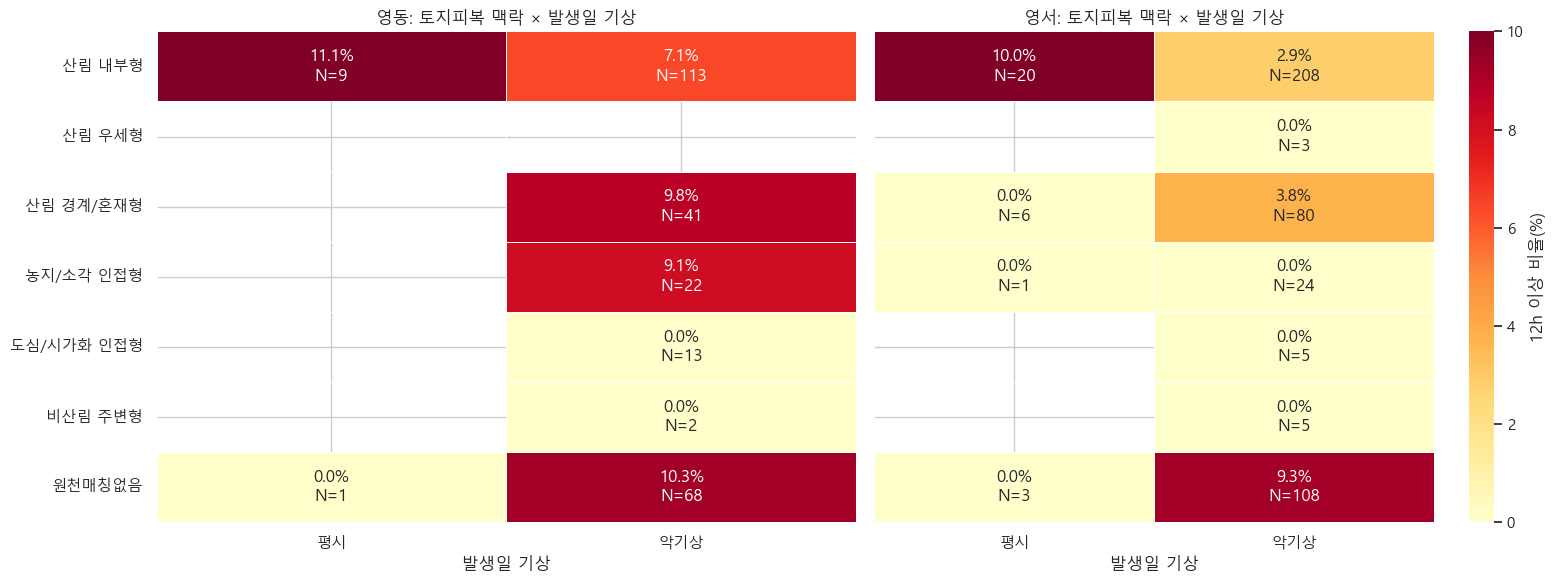

In [4]:
context_order = [
    "산림 내부형",
    "산림 우세형",
    "산림 경계/혼재형",
    "농지/소각 인접형",
    "도심/시가화 인접형",
    "비산림 주변형",
    "원천매칭없음",
]
weather_order = ["평시", "악기상"]

context_weather_summary = (
    df.groupby(["gangwon_region", "landcover_context_type", "weather_peak_label"], observed=False, dropna=False)
    .apply(summarize_group, include_groups=False)
    .reset_index()
)
display(
    context_weather_summary[context_weather_summary["weather_peak_label"].eq("악기상")]
    .sort_values(["gangwon_region", "12h 이상 비율(%)"], ascending=[True, False])
    .round(4)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, region in zip(axes, ["영동", "영서"]):
    region_df = context_weather_summary[context_weather_summary["gangwon_region"].eq(region)]
    heat = (
        region_df
        .pivot(index="landcover_context_type", columns="weather_peak_label", values="12h 이상 비율(%)")
        .reindex(context_order)[weather_order]
    )
    heat_n = (
        region_df
        .pivot(index="landcover_context_type", columns="weather_peak_label", values="진화 유효 N")
        .reindex(context_order)[weather_order]
    )
    annot = heat.copy().astype(object)
    for row in annot.index:
        for col in annot.columns:
            value = heat.loc[row, col]
            n_value = heat_n.loc[row, col]
            annot.loc[row, col] = "" if pd.isna(value) else f"{value:.1f}%\nN={int(n_value)}"
    sns.heatmap(
        heat,
        annot=annot,
        fmt="",
        cmap="YlOrRd",
        linewidths=0.5,
        ax=ax,
        cbar=region == "영서",
        cbar_kws={"label": "12h 이상 비율(%)"},
    )
    ax.set_title(f"{region}: 토지피복 맥락 × 발생일 기상")
    ax.set_xlabel("발생일 기상")
    ax.set_ylabel("")
plt.tight_layout()
fig.savefig(TMP_PLOT_DIR / "01_context_weather_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

### 2-1. 해석 및 플롯 이미지 분석

영동에서는 악기상 조건에서 산림성 토지피복 맥락의 장시간 진화 신호가 영서보다 뚜렷하다. `산림 경계/혼재형`은 12h 이상 비율 **9.76%**(진화 유효 41건), `산림 내부형`은 **7.08%**(113건)이다. `농지/소각 인접형`도 **9.09%**이나 진화 유효 표본이 22건이므로 후보 신호로만 본다.

영서에서는 같은 악기상 조건에서도 `산림 경계/혼재형` **3.75%**, `산림 내부형` **2.88%**로 낮아진다. 이는 토지피복의 산림성 자체보다 영동의 강풍·건조 바람길과 결합될 때 장시간 진화 위험이 커진다는 해석을 지지한다.

`원천매칭없음`은 영동과 영서 모두 높은 12h 비율을 보이지만, 토지피복 의미가 없는 품질 집단이므로 위험 유형으로 해석하지 않는다.

## 3. 발생 직전 24시간 강풍·저습 복합 노출

,gangwon_region,pre24_exposure_grade,전체 N,진화 유효 N,평균 진화시간(h),12h 이상 비율(%),10ha 이상 비율(%),평균 피해면적(ha),중앙 피해면적(ha),90p 피해면적(ha),최대 피해면적(ha)
0,영동,복합노출 없음,765.0,43.0,2.2702,4.6512,0.1307,0.0405,0.0,0.00,13.70
1,영동,1-3h,201.0,40.0,1.6604,0.0000,0.4975,2.2286,0.0,0.10,430.00
2,영동,4-8h,150.0,49.0,4.2469,12.2449,2.6667,9.6923,0.0,0.30,1210.00
3,영동,9h 이상,493.0,137.0,4.1530,10.2190,4.0568,49.1684,0.0,0.70,13343.00
4,영서,복합노출 없음,1667.0,160.0,2.1894,3.1250,0.1200,0.0684,0.0,0.00,43.20
5,영서,1-3h,470.0,131.0,2.3523,6.1069,0.4255,0.7097,0.0,0.20,254.00
6,영서,4-8h,330.0,112.0,2.0275,1.7857,0.6061,0.3401,0.0,0.61,18.00
7,영서,9h 이상,63.0,60.0,3.4153,10.0000,4.7619,6.1529,0.3,2.00,288.87


,gangwon_region,landcover_context_type,전체 N,진화 유효 N,평균 진화시간(h),12h 이상 비율(%),10ha 이상 비율(%),평균 피해면적(ha),중앙 피해면적(ha),90p 피해면적(ha),최대 피해면적(ha)
0,영동,농지/소각 인접형,66.0,14.0,3.3917,14.2857,3.0303,19.9830,0.00,0.15,1296.00
1,영동,도심/시가화 인접형,69.0,9.0,1.7167,0.0000,1.4493,0.6399,0.00,0.06,42.00
2,영동,산림 경계/혼재형,114.0,27.0,5.8889,14.8148,4.3860,139.5155,0.00,0.57,13343.00
3,영동,산림 내부형,141.0,46.0,4.2243,8.6957,3.5461,30.0608,0.00,1.20,4053.40
4,영동,산림 우세형,2.0,0.0,NaN,NaN,0.0000,0.0000,0.00,0.00,0.00
5,영동,원천매칭없음,101.0,41.0,3.7248,9.7561,6.9307,27.0658,0.00,2.00,1420.00
6,영서,농지/소각 인접형,5.0,3.0,0.9389,0.0000,0.0000,0.0800,0.10,0.16,0.20
7,영서,산림 경계/혼재형,10.0,9.0,1.1148,0.0000,0.0000,0.3240,0.30,0.55,1.00
8,영서,산림 내부형,22.0,22.0,2.6402,4.5455,4.5455,1.2545,0.25,2.00,10.00
9,영서,산림 우세형,1.0,1.0,10.0333,0.0000,100.0000,288.8700,288.87,288.87,288.87


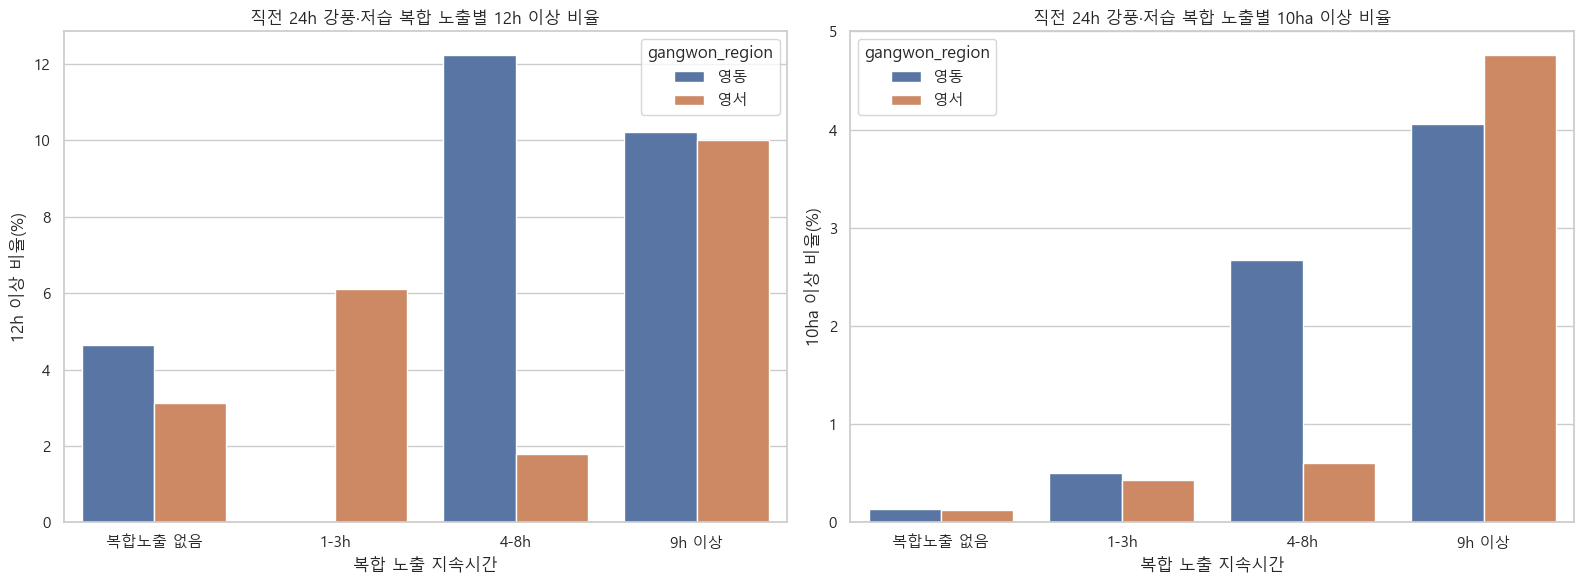

In [5]:
exposure_summary = (
    df.groupby(["gangwon_region", "pre24_exposure_grade"], observed=False, dropna=False)
    .apply(summarize_group, include_groups=False)
    .reset_index()
)
display(exposure_summary.round(4))

exposure_context_9h = (
    df[df["pre24_wind_dry_hours"].ge(9)]
    .groupby(["gangwon_region", "landcover_context_type"], observed=False, dropna=False)
    .apply(summarize_group, include_groups=False)
    .reset_index()
)
display(exposure_context_9h.round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(
    data=exposure_summary,
    x="pre24_exposure_grade",
    y="12h 이상 비율(%)",
    hue="gangwon_region",
    ax=axes[0],
)
axes[0].set_title("직전 24h 강풍·저습 복합 노출별 12h 이상 비율")
axes[0].set_xlabel("복합 노출 지속시간")

sns.barplot(
    data=exposure_summary,
    x="pre24_exposure_grade",
    y="10ha 이상 비율(%)",
    hue="gangwon_region",
    ax=axes[1],
)
axes[1].set_title("직전 24h 강풍·저습 복합 노출별 10ha 이상 비율")
axes[1].set_xlabel("복합 노출 지속시간")
plt.tight_layout()
fig.savefig(TMP_PLOT_DIR / "02_pre24_wind_dry_exposure.png", dpi=160, bbox_inches="tight")
plt.show()

### 3-1. 해석 및 플롯 이미지 분석

발생 직전 24시간 동안 `풍속 >= 3m/s`와 `습도 <= 30%`가 동시에 나타난 시간이 길수록 영동의 피해 꼬리가 커진다. 영동에서 복합 노출 **9시간 이상** 구간은 493건, 진화 유효 137건이며 12h 이상 비율 **10.22%**, 10ha 이상 비율 **4.06%**이다.

특히 영동의 9시간 이상 노출 중 `산림 경계/혼재형`은 12h 이상 비율 **14.81%**, `농지/소각 인접형`은 **14.29%**, `산림 내부형`은 **8.70%**로 나타난다. 다만 평균 피해면적은 13,343ha 같은 초대형 피해에 크게 끌리므로, 평균보다 10ha 이상 여부와 12h 이상 여부를 우선한다.

영서도 9시간 이상 구간의 12h 이상 비율이 **10.00%**로 높지만 전체 63건, 진화 유효 60건이라 강원 전체 규칙으로 일반화하기 전 표본 안정성을 별도로 확인해야 한다.

## 4. 영동권 바람길 정렬과 주변 산림 방향·거리

,gangwon_region,wind_forest_alignment,전체 N,진화 유효 N,평균 진화시간(h),12h 이상 비율(%),10ha 이상 비율(%),평균 피해면적(ha),중앙 피해면적(ha),90p 피해면적(ha),최대 피해면적(ha)
1,영동,사면-풍향정렬,175.0,12.0,6.9472,16.6667,1.1429,9.1827,0.000,0.000,1420.00
2,영동,사면-풍향정렬+근접산림,72.0,13.0,7.3679,15.3846,2.7778,37.1701,0.000,0.097,2243.90
3,영동,사면-풍향정렬+근접산림+E/SE/W/SW,124.0,23.0,2.4804,8.6957,2.4194,108.1511,0.000,0.150,13343.00
0,영동,그 외,1238.0,221.0,3.1896,7.2398,1.5347,6.8488,0.000,0.200,4053.40
5,영서,사면-풍향정렬,175.0,20.0,2.0442,5.0000,0.0000,0.0481,0.000,0.050,5.00
6,영서,사면-풍향정렬+근접산림,34.0,20.0,2.1908,5.0000,2.9412,0.5429,0.075,0.600,10.00
4,영서,그 외,2199.0,408.0,2.4223,4.6569,0.3638,0.4147,0.000,0.100,288.87
7,영서,사면-풍향정렬+근접산림+E/SE/W/SW,122.0,15.0,1.1622,0.0000,0.0000,0.0696,0.000,0.084,5.00


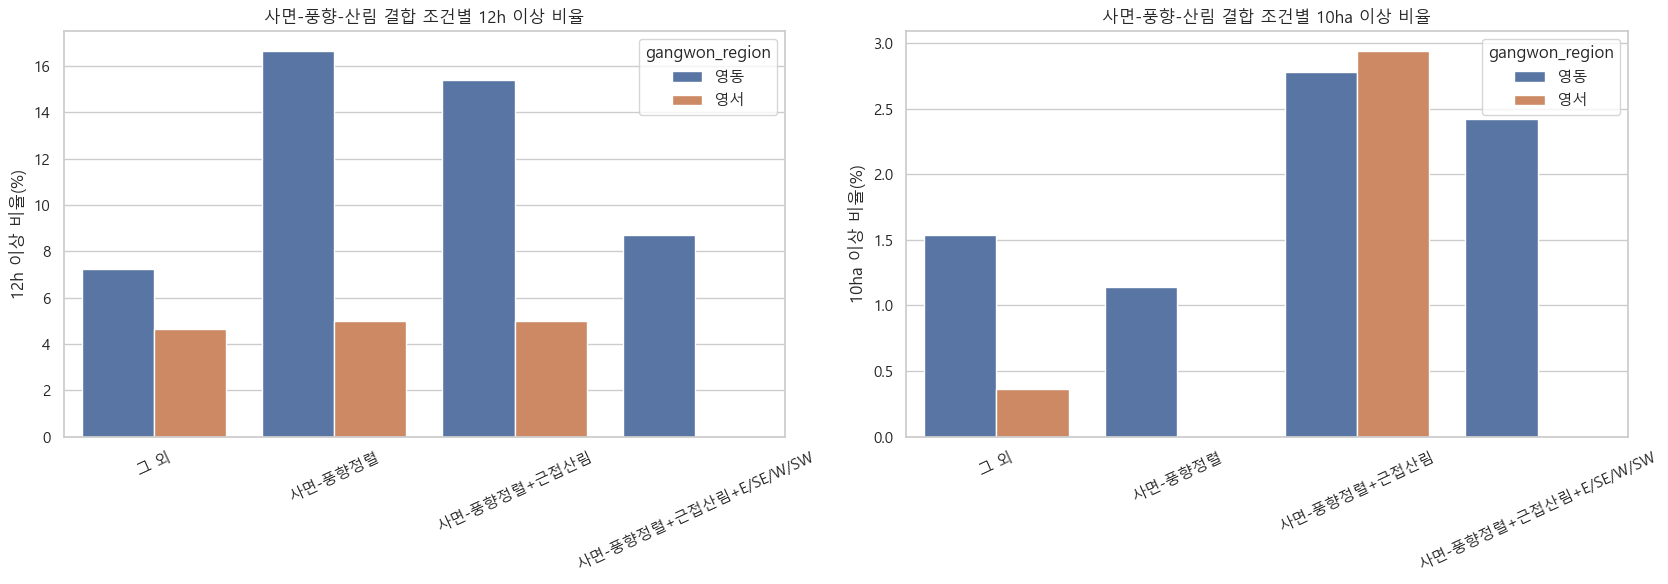

In [6]:
wind_summary = (
    df.groupby(["gangwon_region", "wind_forest_alignment"], observed=False, dropna=False)
    .apply(summarize_group, include_groups=False)
    .reset_index()
    .sort_values(["gangwon_region", "12h 이상 비율(%)"], ascending=[True, False])
)
display(wind_summary.round(4))

alignment_order = ["그 외", "사면-풍향정렬", "사면-풍향정렬+근접산림", "사면-풍향정렬+근접산림+E/SE/W/SW"]
wind_plot = wind_summary.copy()
wind_plot["wind_forest_alignment"] = pd.Categorical(wind_plot["wind_forest_alignment"], alignment_order, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
sns.barplot(
    data=wind_plot.sort_values("wind_forest_alignment"),
    x="wind_forest_alignment",
    y="12h 이상 비율(%)",
    hue="gangwon_region",
    ax=axes[0],
)
axes[0].set_title("사면-풍향-산림 결합 조건별 12h 이상 비율")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=25)

sns.barplot(
    data=wind_plot.sort_values("wind_forest_alignment"),
    x="wind_forest_alignment",
    y="10ha 이상 비율(%)",
    hue="gangwon_region",
    ax=axes[1],
)
axes[1].set_title("사면-풍향-산림 결합 조건별 10ha 이상 비율")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=25)
plt.tight_layout()
fig.savefig(TMP_PLOT_DIR / "03_wind_forest_alignment.png", dpi=160, bbox_inches="tight")
plt.show()

### 4-1. 해석 및 플롯 이미지 분석

영동에서는 W/SW 사면과 W/SW 풍향이 맞는 조합에서 12h 이상 비율이 높게 나타난다. `사면-풍향정렬`은 **16.67%**, `사면-풍향정렬+근접산림`은 **15.38%**이다. 다만 각각 진화 유효 표본이 12건, 13건으로 작아 고정 규칙보다 후보 조건으로 남겨야 한다.

주변 산림 방향까지 `E/SE/W/SW`로 제한한 조합은 12h 이상 비율 **8.70%**로 낮아지지만 최대 피해 13,343ha가 포함되어 평균 피해가 크게 튄다. 이는 전형적 피해 증가가 아니라 대형 피해 꼬리 신호다.

영서에서는 같은 정렬 조건이 장시간 진화 또는 피해 꼬리 증가로 일관되게 이어지지 않는다. 따라서 바람길 정렬 피처는 강원 전체 공통 규칙이 아니라 `영동 여부`와 상호작용으로 넣는 것이 안전하다.

## 5. 발생원인 × 토지피복 맥락 × 악기상

,gangwon_region,cause_group,landcover_context_type,weather_peak_label,전체 N,진화 유효 N,평균 진화시간(h),12h 이상 비율(%),10ha 이상 비율(%),평균 피해면적(ha),중앙 피해면적(ha),90p 피해면적(ha),최대 피해면적(ha)
0,영서,소각/농업활동,산림 경계/혼재형,악기상,24.0,24.0,2.0285,8.3333,4.1667,1.9767,0.10,0.57,43.2
1,영동,입산/산림활동,산림 내부형,악기상,57.0,57.0,3.1591,5.2632,1.7544,71.6623,0.20,2.00,4053.4
2,영서,입산/산림활동,산림 내부형,악기상,118.0,118.0,2.1816,4.2373,2.5424,2.8733,0.15,1.50,254.0
3,영서,입산/산림활동,산림 경계/혼재형,악기상,34.0,34.0,1.7824,2.9412,0.0000,0.5329,0.30,1.35,5.0
4,영서,소각/농업활동,산림 내부형,악기상,39.0,39.0,1.4521,0.0000,0.0000,0.6795,0.30,1.68,5.0


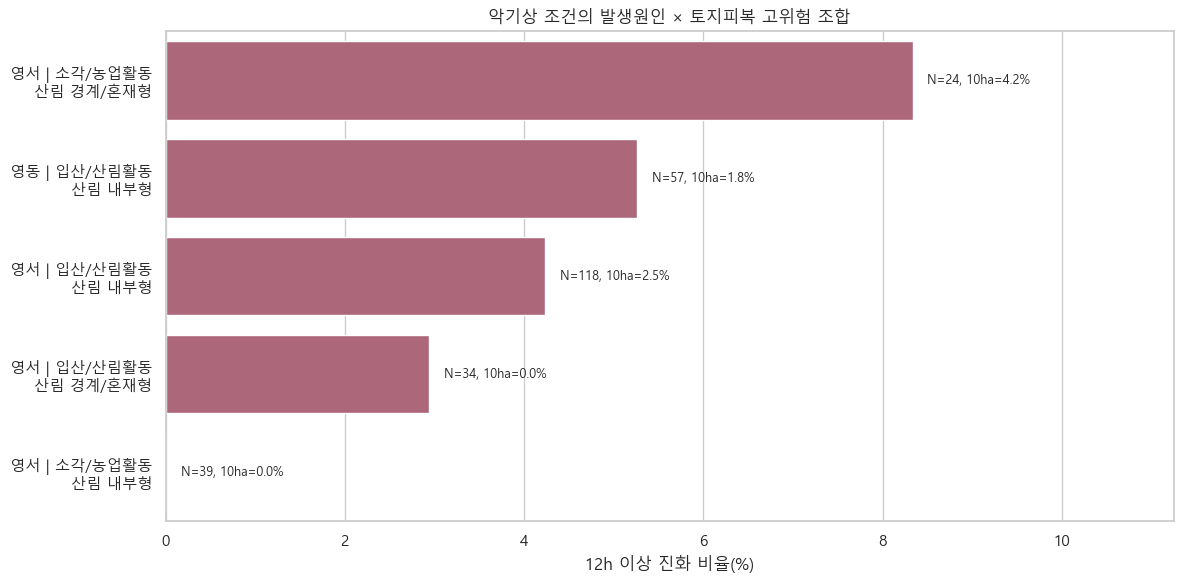

In [7]:
cause_combo = (
    df.groupby(["gangwon_region", "cause_group", "landcover_context_type", "weather_peak_label"], observed=False, dropna=False)
    .apply(summarize_group, include_groups=False)
    .reset_index()
)
cause_actionable = (
    cause_combo[
        cause_combo["weather_peak_label"].eq("악기상")
        & cause_combo["전체 N"].ge(20)
        & cause_combo["진화 유효 N"].ge(10)
        & ~cause_combo["cause_group"].isin(["미상/미기록"])
        & ~cause_combo["landcover_context_type"].eq("원천매칭없음")
    ]
    .sort_values(["12h 이상 비율(%)", "90p 피해면적(ha)"], ascending=[False, False])
    .reset_index(drop=True)
)
display(cause_actionable.round(4))

cause_plot = cause_actionable.head(12).copy()
cause_plot["조합"] = cause_plot["gangwon_region"] + " | " + cause_plot["cause_group"] + "\n" + cause_plot["landcover_context_type"]
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=cause_plot, y="조합", x="12h 이상 비율(%)", color="#b85b75", ax=ax)
x_max = max(cause_plot["12h 이상 비율(%)"].max(), 1)
ax.set_xlim(0, x_max * 1.35)
for i, (_, row) in enumerate(cause_plot.iterrows()):
    ax.text(
        row["12h 이상 비율(%)"] + x_max * 0.02,
        i,
        f"N={int(row['진화 유효 N'])}, 10ha={row['10ha 이상 비율(%)']:.1f}%",
        va="center",
        fontsize=9,
    )
ax.set_title("악기상 조건의 발생원인 × 토지피복 고위험 조합")
ax.set_xlabel("12h 이상 진화 비율(%)")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(TMP_PLOT_DIR / "04_cause_landcover_weather.png", dpi=160, bbox_inches="tight")
plt.show()

### 5-1. 해석 및 플롯 이미지 분석

필터링 기준을 통과한 조합은 많지 않다. 이는 강원도 원인명 표본을 지나치게 세분하면 안정성이 빠르게 낮아진다는 뜻이다.

가장 높은 12h 비율은 `영서 × 소각/농업활동 × 산림 경계/혼재형 × 악기상`의 **8.33%**이나 진화 유효 표본은 24건이다. 영동에서는 `입산/산림활동 × 산림 내부형 × 악기상`이 진화 유효 57건에서 12h 이상 비율 **5.26%**이고, 평균 피해면적은 4,053ha 피해 1건 때문에 크게 상승한다.

따라서 강원도 모델링에서는 원인그룹 단독보다 `입산/산림활동 또는 소각/농업활동 × 산림 내부/경계 × 악기상`의 축약 상호작용으로 쓰는 편이 안정적이다.

## 6. 접근성·원격제어의 조건부 병목

,gangwon_region,access_grade_gw,전체 N,진화 유효 N,평균 진화시간(h),12h 이상 비율(%),10ha 이상 비율(%),평균 피해면적(ha),중앙 피해면적(ha),90p 피해면적(ha),최대 피해면적(ha)
0,영동,접근 우수,570.0,94.0,2.5665,6.3830,1.7544,2.9253,0.0,0.104,1210.00
1,영동,접근 보통,472.0,78.0,3.4932,7.6923,1.6949,36.4997,0.0,0.100,13343.00
2,영동,접근 취약,305.0,87.0,4.5730,10.3448,2.6230,23.8570,0.0,0.420,4053.40
3,영서,접근 우수,533.0,85.0,1.8400,3.5294,0.7505,0.2804,0.0,0.100,43.20
4,영서,접근 보통,475.0,112.0,1.9234,1.7857,0.4211,0.6940,0.0,0.300,254.00
5,영서,접근 취약,802.0,236.0,2.6445,5.9322,0.3741,0.5785,0.0,0.300,288.87


,gangwon_region,access_grade_gw,remote_unavailable,전체 N,진화 유효 N,평균 진화시간(h),12h 이상 비율(%),10ha 이상 비율(%),평균 피해면적(ha),중앙 피해면적(ha),90p 피해면적(ha),최대 피해면적(ha)
0,영동,접근 우수,False,127.0,33.0,1.8975,6.0606,1.5748,0.6464,0.0,0.200,42.00
1,영동,접근 우수,True,443.0,61.0,2.9284,6.5574,1.8059,3.5786,0.0,0.100,1210.00
2,영동,접근 보통,False,51.0,16.0,1.0271,0.0000,1.9608,2.2155,0.0,0.300,109.00
3,영동,접근 보통,True,421.0,62.0,4.1296,9.6774,1.6627,40.6529,0.0,0.100,13343.00
4,영동,접근 취약,False,12.0,4.0,6.7000,25.0000,8.3333,108.2550,0.0,2.703,1296.00
5,영동,접근 취약,True,293.0,83.0,4.4705,9.6386,2.3891,20.4004,0.0,0.300,4053.40
6,영서,접근 우수,False,155.0,20.0,2.1242,5.0000,1.9355,0.4833,0.0,0.042,25.00
7,영서,접근 우수,True,378.0,65.0,1.7526,3.0769,0.2646,0.1971,0.0,0.100,43.20
8,영서,접근 보통,False,78.0,27.0,2.3667,3.7037,1.2821,3.3774,0.0,0.500,254.00
9,영서,접근 보통,True,397.0,85.0,1.7825,1.1765,0.2519,0.1668,0.0,0.200,25.54


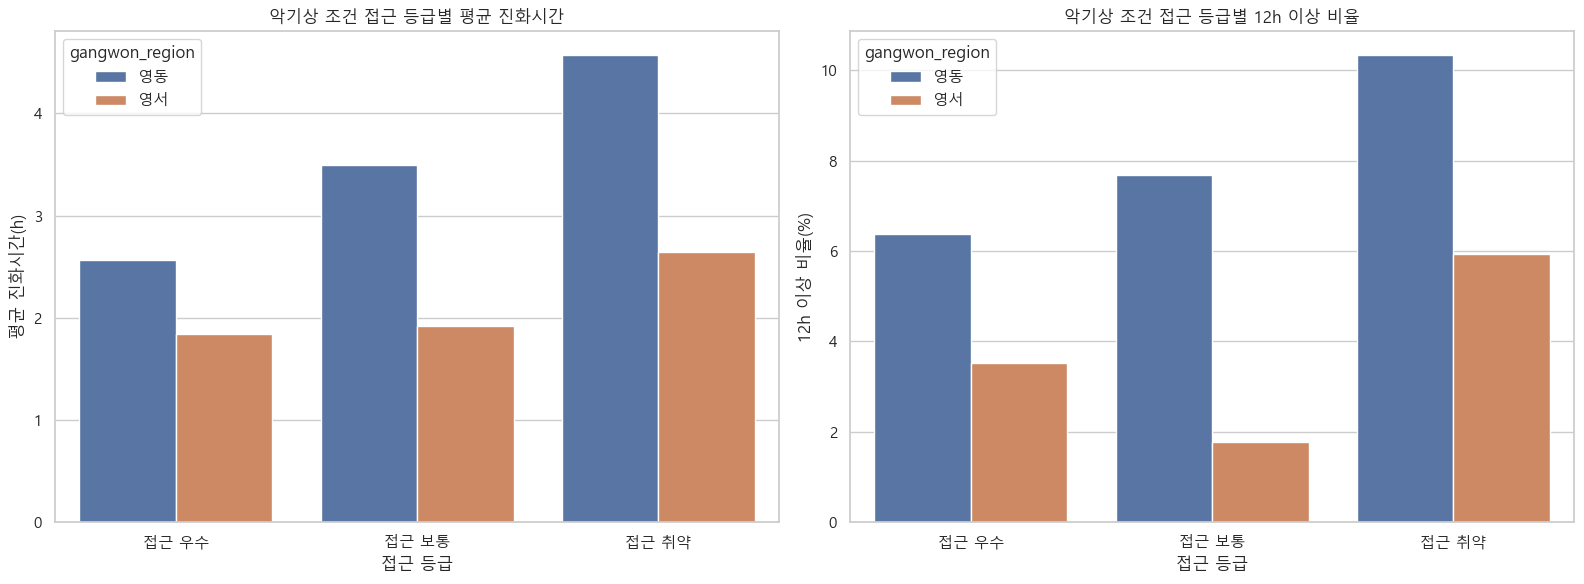

In [8]:
access_summary = (
    df[df["weather_peak_label"].eq("악기상")]
    .groupby(["gangwon_region", "access_grade_gw"], observed=False, dropna=False)
    .apply(summarize_group, include_groups=False)
    .reset_index()
)
display(access_summary.round(4))

remote_access_summary = (
    df[df["weather_peak_label"].eq("악기상")]
    .groupby(["gangwon_region", "access_grade_gw", "remote_unavailable"], observed=False, dropna=False)
    .apply(summarize_group, include_groups=False)
    .reset_index()
)
display(remote_access_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(
    data=access_summary,
    x="access_grade_gw",
    y="평균 진화시간(h)",
    hue="gangwon_region",
    ax=axes[0],
)
axes[0].set_title("악기상 조건 접근 등급별 평균 진화시간")
axes[0].set_xlabel("접근 등급")

sns.barplot(
    data=access_summary,
    x="access_grade_gw",
    y="12h 이상 비율(%)",
    hue="gangwon_region",
    ax=axes[1],
)
axes[1].set_title("악기상 조건 접근 등급별 12h 이상 비율")
axes[1].set_xlabel("접근 등급")
plt.tight_layout()
fig.savefig(TMP_PLOT_DIR / "05_access_bottleneck.png", dpi=160, bbox_inches="tight")
plt.show()

### 6-1. 해석 및 플롯 이미지 분석

악기상 조건에서 영동은 접근 취약 등급으로 갈수록 평균 진화시간과 12h 이상 비율이 함께 증가한다. 영동 접근 우수는 평균 **2.57h**, 12h 이상 **6.38%**이고, 접근 취약은 평균 **4.57h**, 12h 이상 **10.34%**이다.

영서도 접근 취약에서 평균 진화시간 **2.64h**, 12h 이상 **5.93%**로 상승하지만 피해면적 꼬리는 영동보다 약하다. 접근성은 영동에서는 피해 꼬리와 진화 지연을 동시에 키우는 병목에 가깝고, 영서에서는 주로 진화시간 지연 신호로 읽는 편이 안전하다.

원격제어 가능 여부는 선택 편향이 크므로 단독 효과로 해석하지 않는다. 동일한 악기상 조건 안에서도 접근성, 지형, 설치 위치의 선택 편향을 분리하지 않으면 인과 효과로 볼 수 없다.

## 7. 시군구 프로파일과 원자료 표기 품질 점검

,gangwon_region,발생지역시군구명,전체 N,진화 유효 N,악기상 비율(%),산림내부/우세/경계 비율(%),접근취약 비율(%),원격불가 비율(%),12h 이상 비율(%),10ha 이상 비율(%),평균 피해면적(ha),중앙 피해면적(ha),90p 피해면적(ha),최대 피해면적(ha)
5,영동,동해시,477.0,0.0,60.3774,40.2516,2.3061,97.6939,NaN,0.0000,0.0000,0.000,0.000,0.00
11,영동,양양군,343.0,5.0,94.7522,10.4956,38.7755,100.0000,0.0000,0.0000,0.0000,0.000,0.000,0.00
29,영서,평창군,334.0,0.0,64.0719,52.6946,27.5449,100.0000,NaN,0.0000,0.0000,0.000,0.000,0.00
19,영서,원주시,285.0,1.0,77.5439,24.9123,60.3509,83.8596,0.0000,0.0000,0.0000,0.000,0.000,0.00
31,영서,홍천군,254.0,5.0,81.4961,40.5512,41.3386,74.4094,20.0000,0.0000,0.0000,0.000,0.000,0.00
25,영서,철원군,233.0,0.0,42.4893,9.0129,15.0215,21.0300,NaN,0.0000,0.0000,0.000,0.000,0.00
17,영서,영월군,231.0,0.0,46.7532,45.8874,15.1515,98.7013,NaN,0.0000,0.0000,0.000,0.000,0.00
35,영서,횡성군,230.0,1.0,77.8261,30.8696,80.0000,100.0000,0.0000,0.0000,0.0000,0.000,0.000,0.00
1,영동,강릉시,196.0,2.0,92.3469,41.3265,9.6939,28.5714,0.0000,0.0000,0.0000,0.000,0.000,0.00
7,영동,삼척시,174.0,6.0,94.2529,49.4253,37.3563,100.0000,33.3333,0.0000,0.0000,0.000,0.000,0.00


,gangwon_region,발생지역시군구명,전체 N,진화 유효 N,악기상 비율(%),산림내부/우세/경계 비율(%),접근취약 비율(%),원격불가 비율(%),12h 이상 비율(%),10ha 이상 비율(%),평균 피해면적(ha),중앙 피해면적(ha),90p 피해면적(ha),최대 피해면적(ha)
14,영서,양구,23.0,22.0,95.6522,0.0000,100.0000,43.4783,13.6364,4.3478,2.5726,0.10,3.960,42.70
24,영서,철원,25.0,25.0,100.0000,8.0000,24.0000,20.0000,12.0000,8.0000,2.3084,0.50,6.900,18.00
2,영동,고성,43.0,43.0,97.6744,0.0000,39.5349,100.0000,11.6279,16.2791,68.9853,0.25,27.488,1420.00
6,영동,삼척,48.0,48.0,93.7500,93.7500,58.3333,100.0000,10.4167,10.4167,365.0371,0.20,6.850,13343.00
10,영동,양양,26.0,26.0,100.0000,30.7692,46.1538,100.0000,7.6923,11.5385,45.8785,0.50,17.000,973.00
20,영서,인제,52.0,52.0,98.0769,34.6154,59.6154,100.0000,7.6923,1.9231,1.4163,0.30,1.780,43.20
34,영서,횡성,35.0,35.0,88.5714,97.1429,91.4286,100.0000,5.7143,2.8571,8.5603,0.15,0.760,288.87
16,영서,영월,43.0,43.0,90.6977,97.6744,41.8605,95.3488,4.6512,0.0000,0.5700,0.30,1.480,5.00
0,영동,강릉,98.0,98.0,96.9388,76.5306,21.4286,46.9388,4.0816,6.1224,20.3434,0.30,2.150,1296.00
32,영서,화천,26.0,26.0,96.1538,0.0000,69.2308,3.8462,3.8462,0.0000,0.5892,0.10,1.200,5.00


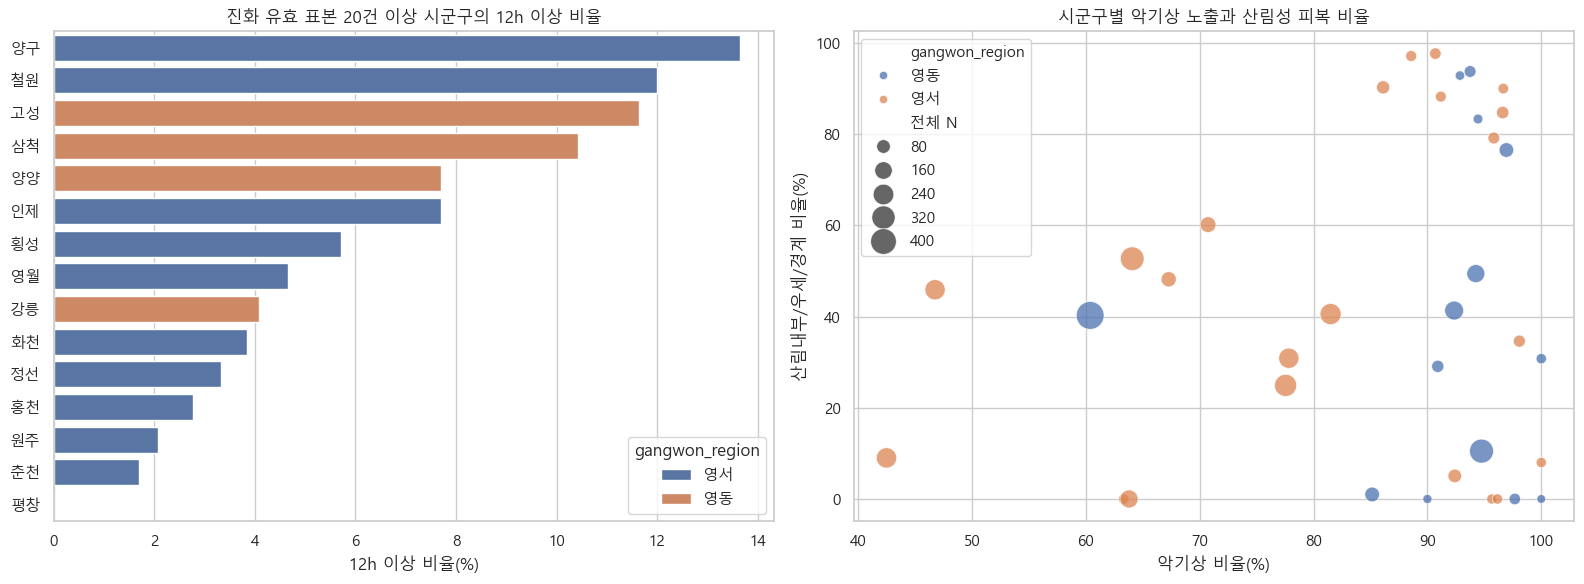

In [9]:
city_profile = (
    df.groupby(["gangwon_region", "발생지역시군구명"], dropna=False)
    .apply(lambda g: pd.Series({
        "전체 N": len(g),
        "진화 유효 N": g["_suppression_valid"].sum(),
        "악기상 비율(%)": g["weather_peak_day"].mean() * 100,
        "산림내부/우세/경계 비율(%)": g["landcover_context_type"].isin(["산림 내부형", "산림 우세형", "산림 경계/혼재형"]).mean() * 100,
        "접근취약 비율(%)": g["access_grade_gw"].astype(str).eq("접근 취약").mean() * 100,
        "원격불가 비율(%)": g["remote_unavailable"].mean() * 100,
        "12h 이상 비율(%)": g.loc[g["_suppression_valid"], "_large_fire_12h"].mean() * 100,
        "10ha 이상 비율(%)": g["_large_damage_10ha"].mean() * 100,
        "평균 피해면적(ha)": g["_damage_ha"].mean(),
        "중앙 피해면적(ha)": g["_damage_ha"].median(),
        "90p 피해면적(ha)": g["_damage_ha"].quantile(0.9),
        "최대 피해면적(ha)": g["_damage_ha"].max(),
    }), include_groups=False)
    .reset_index()
)
display(city_profile.sort_values("전체 N", ascending=False).round(4))

city_valid_profile = (
    city_profile[city_profile["진화 유효 N"].ge(20)]
    .sort_values(["12h 이상 비율(%)", "90p 피해면적(ha)"], ascending=[False, False])
)
display(city_valid_profile.round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(
    data=city_valid_profile,
    y="발생지역시군구명",
    x="12h 이상 비율(%)",
    hue="gangwon_region",
    dodge=False,
    ax=axes[0],
)
axes[0].set_title("진화 유효 표본 20건 이상 시군구의 12h 이상 비율")
axes[0].set_ylabel("")

sns.scatterplot(
    data=city_profile,
    x="악기상 비율(%)",
    y="산림내부/우세/경계 비율(%)",
    size="전체 N",
    hue="gangwon_region",
    sizes=(40, 400),
    alpha=0.75,
    ax=axes[1],
)
axes[1].set_title("시군구별 악기상 노출과 산림성 피복 비율")
plt.tight_layout()
fig.savefig(TMP_PLOT_DIR / "06_city_profile_quality.png", dpi=160, bbox_inches="tight")
plt.show()

### 7-1. 시군구 프로파일 해석 및 품질 주의

원자료 시군구명은 `강릉`과 `강릉시`, `홍천`과 `홍천군`처럼 표기가 나뉜다. 더 중요한 문제는 일부 표기군은 전체 N은 크지만 진화 유효 표본이 거의 없다는 점이다. 예를 들어 `동해시`, `평창군`, `철원군` 등은 전체 표본은 많지만 유효 진화시간이 0건으로 나타난다.

따라서 시군구별 순위는 원자료 표기와 타깃 유효성 점검 없이는 모델링 가중치로 쓰면 안 된다. 진화 유효 표본 20건 이상인 표기군만 보면 `양구`, `철원`, `고성`, `삼척`, `양양`, `인제`, `강릉`, `홍천`, `춘천` 등이 남는다. 이 중 `고성`, `삼척`, `양양`, `강릉`은 영동권 대형 피해 꼬리와 연결되는 후보지만, 접미사 포함 표기(`고성군`, `삼척시`, `양양군`, `강릉시`)와 별도 집단으로 나뉘므로 표준화 전에는 합산 해석하지 않는다.

다음 단계에서는 시군구 표준화 테이블을 별도로 만든 뒤, 표준화 전후 표본 수와 진화 유효 N이 어떻게 변하는지 감사해야 한다.

## 8. 피해면적 꼬리 민감도와 모델링 후보

In [10]:
tail_summary = (
    df[df["weather_peak_label"].eq("악기상")]
    .groupby(["gangwon_region", "landcover_context_type"], observed=False, dropna=False)
    .apply(lambda g: pd.Series({
        "전체 N": len(g),
        "10ha 이상 비율(%)": g["_large_damage_10ha"].mean() * 100,
        "평균 피해면적(ha)": g["_damage_ha"].mean(),
        "중앙 피해면적(ha)": g["_damage_ha"].median(),
        "90p 피해면적(ha)": g["_damage_ha"].quantile(0.9),
        "최대 피해면적(ha)": g["_damage_ha"].max(),
        "상위1건 피해비중(%)": (
            g["_damage_ha"].dropna().sort_values(ascending=False).iloc[0] / g["_damage_ha"].sum() * 100
            if g["_damage_ha"].sum() else np.nan
        ),
    }), include_groups=False)
    .reset_index()
    .sort_values(["gangwon_region", "10ha 이상 비율(%)"], ascending=[True, False])
)
display(tail_summary.round(4))

model_feature_candidates = pd.DataFrame([
    {"피처": "gangwon_region", "의미": "영동/영서 구분", "활용": "강원도 내 물리 메커니즘 분리"},
    {"피처": "weather_peak_day", "의미": "발생일 강풍 또는 저습 피크", "활용": "토지피복 위험이 발현되는 기상 관문"},
    {"피처": "pre24_wind_dry_hours", "의미": "직전 24h 강풍·저습 동시 노출 시간", "활용": "누적 건조·강풍 노출 강도"},
    {"피처": "landcover_context_type", "의미": "발생점 주변 토지피복 맥락", "활용": "산림 내부/경계/농지/도심 구분"},
    {"피처": "landcover_missing_flag", "의미": "원천 토지피복 매칭 없음", "활용": "비산림과 품질 이슈 분리"},
    {"피처": "aspect_wind_ws_match", "의미": "W/SW 사면과 W/SW 풍향 정렬", "활용": "영동 바람길 상호작용"},
    {"피처": "forest_near_30m", "의미": "산림 30m 이내 존재", "활용": "발생점-산림 접촉성"},
    {"피처": "forest_dominant_direction", "의미": "주변 산림 우세 방위", "활용": "풍향·사면방향과 결합"},
    {"피처": "cause_group", "의미": "발생원인 그룹", "활용": "입산/소각/도로 등 행동 맥락"},
    {"피처": "access_burden_index", "의미": "소방서·소화시설·소방용수·등산로 거리 기반 접근 부담", "활용": "조건부 진화 지연 병목"},
    {"피처": "remote_unavailable", "의미": "산불소화시설 원격제어 불가능", "활용": "선택 편향 주의, 접근성과 함께 검토"},
])
display(model_feature_candidates)

,gangwon_region,landcover_context_type,전체 N,10ha 이상 비율(%),평균 피해면적(ha),중앙 피해면적(ha),90p 피해면적(ha),최대 피해면적(ha),상위1건 피해비중(%)
3,영동,산림 경계/혼재형,237.0,2.9536,67.3073,0.000,0.200,13343.00,83.6456
6,영동,원천매칭없음,377.0,2.6525,11.0062,0.000,0.200,1420.00,34.2223
4,영동,산림 내부형,295.0,2.0339,15.9535,0.000,0.920,4053.40,86.1277
0,영동,농지/소각 인접형,194.0,1.0309,6.7988,0.000,0.000,1296.00,98.2585
1,영동,도심/시가화 인접형,235.0,0.4255,0.1926,0.000,0.000,42.00,92.7767
2,영동,비산림 주변형,2.0,0.0000,0.0050,0.005,0.009,0.01,100.0000
5,영동,산림 우세형,7.0,0.0000,0.0000,0.000,0.000,0.00,NaN
12,영서,산림 우세형,13.0,7.6923,22.2246,0.000,0.040,288.87,99.9827
13,영서,원천매칭없음,393.0,0.7634,0.3938,0.000,0.500,42.70,27.5893
11,영서,산림 내부형,478.0,0.6276,0.8181,0.000,0.500,254.00,64.9500


,피처,의미,활용
0,gangwon_region,영동/영서 구분,강원도 내 물리 메커니즘 분리
1,weather_peak_day,발생일 강풍 또는 저습 피크,토지피복 위험이 발현되는 기상 관문
2,pre24_wind_dry_hours,직전 24h 강풍·저습 동시 노출 시간,누적 건조·강풍 노출 강도
3,landcover_context_type,발생점 주변 토지피복 맥락,산림 내부/경계/농지/도심 구분
4,landcover_missing_flag,원천 토지피복 매칭 없음,비산림과 품질 이슈 분리
5,aspect_wind_ws_match,W/SW 사면과 W/SW 풍향 정렬,영동 바람길 상호작용
6,forest_near_30m,산림 30m 이내 존재,발생점-산림 접촉성
7,forest_dominant_direction,주변 산림 우세 방위,풍향·사면방향과 결합
8,cause_group,발생원인 그룹,입산/소각/도로 등 행동 맥락
9,access_burden_index,소방서·소화시설·소방용수·등산로 거리 기반 접근 부담,조건부 진화 지연 병목


### 8-1. 기존 심화 분석 정리

강원도 심화 분석에서는 영동/영서 분리가 가장 중요하다. 같은 악기상·산림성 피복 조건이라도 영동은 장시간 진화와 대형 피해 꼬리로 이어지는 신호가 강하고, 영서는 주로 진화 지연 또는 소규모 피해로 억제되는 경우가 많다.

다만 아래의 타깃 품질 감사와 임계값 민감도 분석을 통해, 모델링 전에는 진화소요시간 0값과 피해면적 0값의 의미를 먼저 분리하고 기상 임계값을 고정 규칙이 아닌 연속/구간형 피처로 다루는 것이 필요하다고 판단했다.

## 9. 타깃 품질 감사

지금까지의 강원도 심화 분석은 진화소요시간이 0보다 큰 표본만 유효 진화시간으로 해석했다.
여기서는 이 기준이 왜 필요한지, `12h 이상`, `10ha 이상`, `log1p(피해면적)` 중 어떤 타깃이 모델링에 더 안정적인지 확인한다.

In [11]:
df["_suppression_status"] = np.select(
    [df["_suppression_hours"].isna(), df["_suppression_hours"].eq(0), df["_suppression_hours"].gt(0)],
    ["결측", "0시간", "양수"],
    default="기타",
)
df["_damage_status"] = np.select(
    [df["_damage_ha"].isna(), df["_damage_ha"].eq(0), df["_damage_ha"].between(0, 10, inclusive="left"), df["_damage_ha"].ge(10)],
    ["결측", "0ha", "0-10ha", "10ha 이상"],
    default="기타",
)
df["_log_damage"] = np.log1p(df["_damage_ha"].clip(lower=0))

target_quality = pd.DataFrame({
    "전체 N": [len(df)],
    "진화 양수 N": [df["_suppression_status"].eq("양수").sum()],
    "진화 0시간 N": [df["_suppression_status"].eq("0시간").sum()],
    "진화 결측 N": [df["_suppression_status"].eq("결측").sum()],
    "피해 양수 N": [df["_damage_ha"].gt(0).sum()],
    "피해 0ha N": [df["_damage_ha"].eq(0).sum()],
    "12h 이상 N": [int(df["_large_fire_12h"].sum())],
    "10ha 이상 N": [int(df["_large_damage_10ha"].sum())],
})
display(target_quality)

damage_bin = np.select(
    [df["_damage_ha"].isna(), df["_damage_ha"].eq(0), df["_damage_ha"].between(0, 10, inclusive="left"), df["_damage_ha"].ge(10)],
    ["결측", "0ha", "0-10ha", "10ha 이상"],
    default="기타",
)
target_overlap = pd.crosstab(df["_suppression_status"], damage_bin)
display(target_overlap)

target_valid_df = df[df["_suppression_valid"]].copy()
target_candidates = pd.DataFrame([
    {
        "타깃": "12h 이상 진화 여부",
        "학습가능 N": len(target_valid_df),
        "양성 N": int(target_valid_df["_large_fire_12h"].sum()),
        "양성률(%)": target_valid_df["_large_fire_12h"].mean() * 100,
        "주의": "진화 양수 표본만 사용 가능",
    },
    {
        "타깃": "10ha 이상 피해 여부(전체)",
        "학습가능 N": len(df),
        "양성 N": int(df["_large_damage_10ha"].sum()),
        "양성률(%)": df["_large_damage_10ha"].mean() * 100,
        "주의": "0시간/0ha 행을 참 음성으로 볼지 감사 필요",
    },
    {
        "타깃": "10ha 이상 피해 여부(진화 양수)",
        "학습가능 N": len(target_valid_df),
        "양성 N": int(target_valid_df["_large_damage_10ha"].sum()),
        "양성률(%)": target_valid_df["_large_damage_10ha"].mean() * 100,
        "주의": "표본은 작지만 타깃 품질은 상대적으로 안정",
    },
    {
        "타깃": "log1p(피해면적)",
        "학습가능 N": df["_damage_ha"].notna().sum(),
        "양성 N": int(df["_damage_ha"].gt(0).sum()),
        "양성률(%)": df["_damage_ha"].gt(0).mean() * 100,
        "주의": "0ha 과다, 꼬리 완화용 회귀 타깃",
    },
])
display(target_candidates.round(4))

city_target_quality = (
    df.groupby(["gangwon_region", "발생지역시군구명"], dropna=False)
    .agg(
        전체_N=("fire_id", "count"),
        진화_양수_N=("_suppression_status", lambda s: s.eq("양수").sum()),
        진화_0시간_N=("_suppression_status", lambda s: s.eq("0시간").sum()),
        피해_양수_N=("_damage_ha", lambda s: s.gt(0).sum()),
        피해_10ha_N=("_large_damage_10ha", "sum"),
    )
    .reset_index()
)
city_target_quality["진화_양수율(%)"] = city_target_quality["진화_양수_N"] / city_target_quality["전체_N"] * 100
city_target_quality["피해_양수율(%)"] = city_target_quality["피해_양수_N"] / city_target_quality["전체_N"] * 100
display(city_target_quality.sort_values("전체_N", ascending=False).head(25).round(3))

,전체 N,진화 양수 N,진화 0시간 N,진화 결측 N,피해 양수 N,피해 0ha N,12h 이상 N,10ha 이상 N
0,4139,732,3407,0,698,3441,43,35


col_0,0-10ha,0ha,10ha 이상
_suppression_status,,,
0시간,1,3406,0
양수,662,35,35


,타깃,학습가능 N,양성 N,양성률(%),주의
0,12h 이상 진화 여부,732,43,5.8743,진화 양수 표본만 사용 가능
1,10ha 이상 피해 여부(전체),4139,35,0.8456,0시간/0ha 행을 참 음성으로 볼지 감사 필요
2,10ha 이상 피해 여부(진화 양수),732,35,4.7814,표본은 작지만 타깃 품질은 상대적으로 안정
3,log1p(피해면적),4139,698,16.8640,"0ha 과다, 꼬리 완화용 회귀 타깃"


,gangwon_region,발생지역시군구명,전체_N,진화_양수_N,진화_0시간_N,피해_양수_N,피해_10ha_N,진화_양수율(%),피해_양수율(%)
5,영동,동해시,477,0,477,0,0,0.000,0.00
11,영동,양양군,343,5,338,0,0,1.458,0.00
29,영서,평창군,334,0,334,0,0,0.000,0.00
19,영서,원주시,285,1,284,0,0,0.351,0.00
31,영서,홍천군,254,5,249,0,0,1.969,0.00
25,영서,철원군,233,0,233,0,0,0.000,0.00
17,영서,영월군,231,0,231,0,0,0.000,0.00
35,영서,횡성군,230,1,229,0,0,0.435,0.00
1,영동,강릉시,196,2,194,0,0,1.020,0.00
7,영동,삼척시,174,6,168,0,0,3.448,0.00


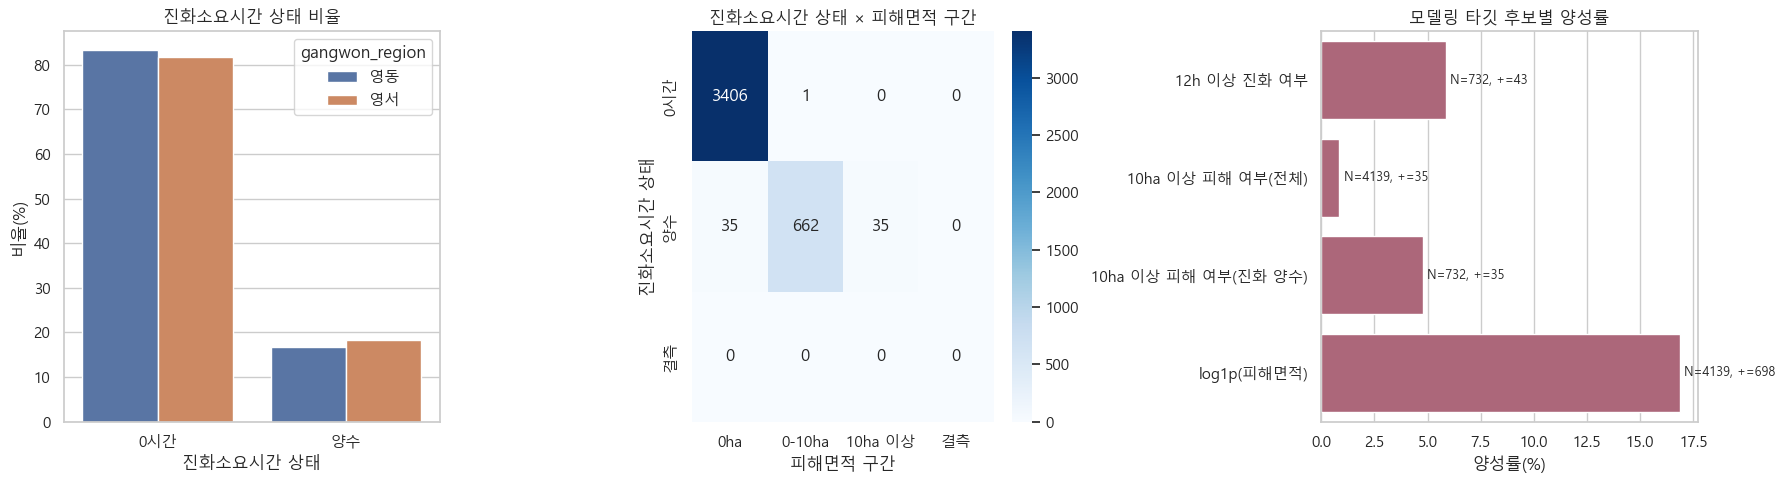

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

status_plot = (
    df.groupby(["gangwon_region", "_suppression_status"])
    .size()
    .reset_index(name="N")
)
status_plot["비율(%)"] = status_plot["N"] / status_plot.groupby("gangwon_region")["N"].transform("sum") * 100
sns.barplot(data=status_plot, x="_suppression_status", y="비율(%)", hue="gangwon_region", ax=axes[0])
axes[0].set_title("진화소요시간 상태 비율")
axes[0].set_xlabel("진화소요시간 상태")

overlap_order = target_overlap.reindex(index=["0시간", "양수", "결측"], columns=["0ha", "0-10ha", "10ha 이상", "결측"], fill_value=0)
sns.heatmap(overlap_order, annot=True, fmt=".0f", cmap="Blues", ax=axes[1])
axes[1].set_title("진화소요시간 상태 × 피해면적 구간")
axes[1].set_xlabel("피해면적 구간")
axes[1].set_ylabel("진화소요시간 상태")

target_plot = target_candidates.copy()
sns.barplot(data=target_plot, y="타깃", x="양성률(%)", color="#b85b75", ax=axes[2])
for i, (_, row) in enumerate(target_plot.iterrows()):
    axes[2].text(row["양성률(%)"] + 0.2, i, f"N={int(row['학습가능 N'])}, +={int(row['양성 N'])}", va="center", fontsize=9)
axes[2].set_title("모델링 타깃 후보별 양성률")
axes[2].set_ylabel("")
plt.tight_layout()
fig.savefig(TMP_PLOT_DIR / "07_target_quality_audit.png", dpi=160, bbox_inches="tight")
plt.show()

### 9-1. 타깃 품질 해석 및 플롯 이미지 분석

강원도 4,139건 중 진화소요시간이 양수인 표본은 **732건**이고, **3,407건**은 0시간이다. 0시간 행은 거의 모두 0ha와 같이 나타나며, 시군구명도 `동해시`, `평창군`, `철원군`처럼 접미사가 붙은 표기군에 집중된다. 반대로 `강릉`, `홍천`, `인제`처럼 접미사가 없는 표기군은 진화 양수율과 피해 양수율이 100%에 가깝다.

따라서 0시간·0ha를 그대로 “안전한 음성”으로 두면 모델이 원자료 표기/타깃 수집 상태를 학습할 위험이 크다. `10ha 이상 피해 여부`를 전체 4,139건 기준으로 만들면 양성률은 **0.85%**로 지나치게 희소하고, 이 중 상당수 음성은 실제 무피해라기보다 타깃 미기록 또는 0처리 가능성이 있다.

모델링 타깃은 우선 `12h 이상 진화 여부`(진화 양수 732건 기준, 양성 43건, **5.87%**)와 `10ha 이상 피해 여부(진화 양수 표본 기준)`를 병행 검토하는 것이 안전하다. 전체 표본을 쓰는 경우에는 반드시 `target_valid_flag` 또는 `suppression_positive_flag`를 별도로 둬야 한다.

## 10. 임계값 민감도 분석

기존 분석에서 사용한 `평균 풍속 >= 3m/s`, `최소 상대습도 <= 30%`, `직전 24h 강풍·저습 복합 노출 9h 이상`이 고정 임계값으로 충분히 안정적인지 확인한다.

In [13]:
def summarize_condition(data, mask):
    sub = data.loc[mask.fillna(False)].copy()
    valid = sub[sub["_suppression_valid"]]
    return pd.Series({
        "조건 N": len(sub),
        "진화 유효 N": len(valid),
        "12h 이상 비율(%)": valid["_large_fire_12h"].mean() * 100 if len(valid) else np.nan,
        "10ha 이상 비율(%)": sub["_large_damage_10ha"].mean() * 100 if len(sub) else np.nan,
        "평균 피해면적(ha)": sub["_damage_ha"].mean(),
        "90p 피해면적(ha)": sub["_damage_ha"].quantile(0.9),
        "최대 피해면적(ha)": sub["_damage_ha"].max(),
    })

wind_rows = []
for region in ["영동", "영서"]:
    region_df = df[df["gangwon_region"].eq(region)]
    for threshold in [2.5, 3.0, 3.5, 4.0, 4.5, 5.0]:
        row = summarize_condition(region_df, region_df["평균 풍속"].ge(threshold))
        row["지역"] = region
        row["임계값"] = threshold
        row["지표"] = "평균풍속"
        wind_rows.append(row)
wind_sensitivity = pd.DataFrame(wind_rows)
display(wind_sensitivity.round(4))

humidity_rows = []
for region in ["영동", "영서"]:
    region_df = df[df["gangwon_region"].eq(region)]
    for threshold in [20, 25, 30, 35, 40]:
        row = summarize_condition(region_df, region_df["최소 상대습도"].le(threshold))
        row["지역"] = region
        row["임계값"] = threshold
        row["지표"] = "최소습도"
        humidity_rows.append(row)
humidity_sensitivity = pd.DataFrame(humidity_rows)
display(humidity_sensitivity.round(4))

exposure_rows = []
key_context_mask = df["landcover_context_type"].isin(["산림 내부형", "산림 경계/혼재형", "산림 우세형"])
for region in ["영동", "영서"]:
    region_df = df[df["gangwon_region"].eq(region)]
    region_key_df = df[df["gangwon_region"].eq(region) & key_context_mask]
    for threshold in [1, 4, 8, 9, 12]:
        row = summarize_condition(region_df, region_df["pre24_wind_dry_hours"].ge(threshold))
        row["지역"] = region
        row["임계값"] = threshold
        row["집단"] = "전체"
        exposure_rows.append(row)

        key_row = summarize_condition(region_key_df, region_key_df["pre24_wind_dry_hours"].ge(threshold))
        key_row["지역"] = region
        key_row["임계값"] = threshold
        key_row["집단"] = "산림성 피복"
        exposure_rows.append(key_row)
exposure_sensitivity = pd.DataFrame(exposure_rows)
display(exposure_sensitivity.round(4))

,조건 N,진화 유효 N,12h 이상 비율(%),10ha 이상 비율(%),평균 피해면적(ha),90p 피해면적(ha),최대 피해면적(ha),지역,임계값,지표
0,998.0,179.0,11.1732,2.4048,26.1627,0.200,13343.0,영동,2.5,평균풍속
1,733.0,143.0,11.8881,3.1378,35.3521,0.300,13343.0,영동,3.0,평균풍속
2,403.0,114.0,13.1579,5.2109,61.7997,1.000,13343.0,영동,3.5,평균풍속
3,243.0,87.0,13.7931,7.4074,45.6542,2.000,4053.4,영동,4.0,평균풍속
4,132.0,63.0,19.0476,12.8788,83.7237,27.736,4053.4,영동,4.5,평균풍속
5,76.0,44.0,22.7273,18.4211,142.7063,56.000,4053.4,영동,5.0,평균풍속
6,334.0,44.0,6.8182,0.5988,0.2399,0.100,42.7,영서,2.5,평균풍속
7,250.0,26.0,11.5385,0.4000,0.1037,0.021,10.0,영서,3.0,평균풍속
8,103.0,16.0,18.7500,0.9709,0.1757,0.100,10.0,영서,3.5,평균풍속
9,56.0,9.0,33.3333,1.7857,0.2384,0.150,10.0,영서,4.0,평균풍속


,조건 N,진화 유효 N,12h 이상 비율(%),10ha 이상 비율(%),평균 피해면적(ha),90p 피해면적(ha),최대 피해면적(ha),지역,임계값,지표
0,630.0,144.0,9.7222,3.0159,41.0170,0.50,13343.00,영동,20,최소습도
1,889.0,197.0,9.6447,2.8121,29.3830,0.32,13343.00,영동,25,최소습도
2,1106.0,221.0,9.0498,2.3508,23.6481,0.20,13343.00,영동,30,최소습도
3,1206.0,240.0,8.3333,2.1559,21.6921,0.20,13343.00,영동,35,최소습도
4,1321.0,253.0,8.6957,1.9682,19.8077,0.20,13343.00,영동,40,최소습도
5,563.0,257.0,5.8366,1.4210,1.5436,1.00,288.87,영서,20,최소습도
6,1060.0,338.0,5.0296,0.7547,0.8547,0.50,288.87,영서,25,최소습도
7,1320.0,389.0,4.6272,0.6818,0.7066,0.31,288.87,영서,30,최소습도
8,1577.0,417.0,4.3165,0.5707,0.5952,0.30,288.87,영서,35,최소습도
9,1783.0,432.0,4.3981,0.5048,0.5290,0.30,288.87,영서,40,최소습도


,조건 N,진화 유효 N,12h 이상 비율(%),10ha 이상 비율(%),평균 피해면적(ha),90p 피해면적(ha),최대 피해면적(ha),지역,임계값,집단
0,844.0,226.0,8.8496,2.9621,30.9737,0.500,13343.00,영동,1,전체
1,422.0,136.0,8.0882,3.0806,48.9208,0.790,13343.00,영동,1,산림성 피복
2,643.0,186.0,10.7527,3.7325,39.9594,0.700,13343.00,영동,4,전체
3,338.0,105.0,10.4762,3.5503,59.7575,0.700,13343.00,영동,4,산림성 피복
4,520.0,146.0,10.9589,4.0385,46.6861,0.710,13343.00,영동,8,전체
5,277.0,82.0,12.1951,3.9711,72.8522,0.880,13343.00,영동,8,산림성 피복
6,493.0,137.0,10.2190,4.0568,49.1684,0.700,13343.00,영동,9,전체
7,257.0,73.0,10.9589,3.8911,78.3788,0.880,13343.00,영동,9,산림성 피복
8,302.0,109.0,10.0917,5.6291,35.2468,1.500,4053.40,영동,12,전체
9,156.0,56.0,8.9286,4.4872,42.0362,1.500,4053.40,영동,12,산림성 피복


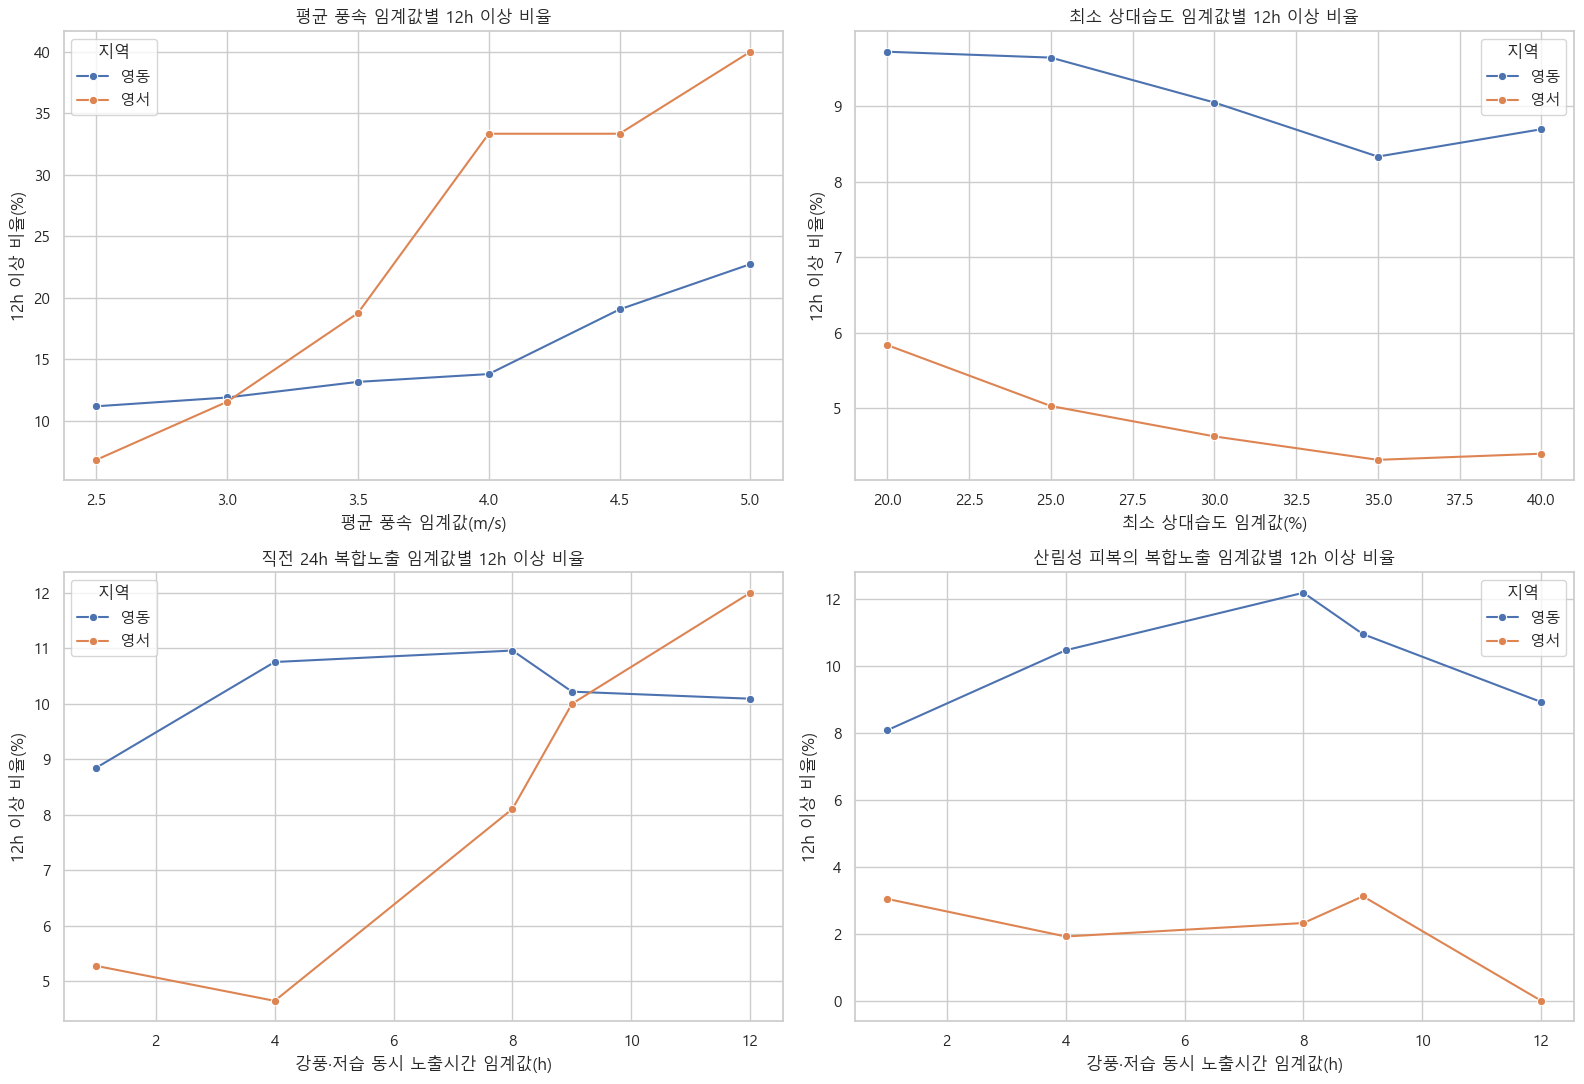

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.lineplot(data=wind_sensitivity, x="임계값", y="12h 이상 비율(%)", hue="지역", marker="o", ax=axes[0, 0])
axes[0, 0].set_title("평균 풍속 임계값별 12h 이상 비율")
axes[0, 0].set_xlabel("평균 풍속 임계값(m/s)")

sns.lineplot(data=humidity_sensitivity, x="임계값", y="12h 이상 비율(%)", hue="지역", marker="o", ax=axes[0, 1])
axes[0, 1].set_title("최소 상대습도 임계값별 12h 이상 비율")
axes[0, 1].set_xlabel("최소 상대습도 임계값(%)")

exposure_plot = exposure_sensitivity[exposure_sensitivity["집단"].eq("전체")]
sns.lineplot(data=exposure_plot, x="임계값", y="12h 이상 비율(%)", hue="지역", marker="o", ax=axes[1, 0])
axes[1, 0].set_title("직전 24h 복합노출 임계값별 12h 이상 비율")
axes[1, 0].set_xlabel("강풍·저습 동시 노출시간 임계값(h)")

key_plot = exposure_sensitivity[exposure_sensitivity["집단"].eq("산림성 피복")]
sns.lineplot(data=key_plot, x="임계값", y="12h 이상 비율(%)", hue="지역", marker="o", ax=axes[1, 1])
axes[1, 1].set_title("산림성 피복의 복합노출 임계값별 12h 이상 비율")
axes[1, 1].set_xlabel("강풍·저습 동시 노출시간 임계값(h)")

plt.tight_layout()
fig.savefig(TMP_PLOT_DIR / "08_threshold_sensitivity.png", dpi=160, bbox_inches="tight")
plt.show()

### 10-1. 임계값 민감도 해석 및 플롯 이미지 분석

평균 풍속 임계값은 영동에서 단조롭게 위험 신호가 강해진다. 영동의 12h 이상 비율은 평균 풍속 2.5m/s 이상에서 **11.17%**, 3.0m/s 이상에서 **11.89%**, 4.0m/s 이상에서 **13.79%**, 5.0m/s 이상에서 **22.73%**까지 오른다. 다만 5.0m/s 기준은 진화 유효 44건으로 표본이 작아 고정 규칙보다는 고위험 상위 구간으로 본다.

최소 상대습도 임계값은 영동에서 20~30% 구간이 **9%대**로 비교적 안정적이고, 임계값을 35~40%까지 완화하면 신호가 약해진다. 따라서 `최소 상대습도 <= 30%`는 해석 가능한 보수적 기준이지만, 단독 피처보다 풍속 및 토지피복과 결합해야 한다.

직전 24시간 강풍·저습 복합노출은 영동에서 4h 이상부터 12h 이상 비율이 **10%대**로 안정된다. 9h 이상이 유일한 절대 임계값이라기보다, `4~8h 이상 누적 노출`부터 위험이 커지는 구조로 보는 편이 안전하다. 산림성 피복으로 제한하면 영동은 8h 이상에서 **12.20%**, 9h 이상에서 **10.96%**로 유지되지만, 영서는 표본이 줄면서 불안정해진다.

결론적으로 모델 피처는 고정 이진값 하나보다 `pre24_wind_dry_hours` 연속값 또는 구간형 피처와 `영동 × 산림성 피복` 상호작용으로 구성하는 것이 낫다.